# Laboratorio: ajuste del modelo SIR a datos (la epidemia del internado) — guía del docente

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jfbonder/imc/blob/main/notebooks/docente/lab-SIR.ipynb)

> Versión con las soluciones completas. La versión para estudiantes, con esqueletos en lugar de las soluciones, es `notebooks/lab-SIR.ipynb`.

Este laboratorio cierra el primer problema conductor de las notas: la epidemia. Con la teoría del Capítulo 2 respondimos las preguntas 1 a 4 (¿hay epidemia?, ¿cuándo es el pico?, ¿cuánta gente queda sin contagiarse?, ¿qué hace la vacunación?) en términos de un único número, $R_0$. Quedó pendiente la pregunta 5: **dada una curva de casos observados, ¿podemos estimar los parámetros del modelo y usarlo para predecir?** Eso es lo que hacemos acá, con los datos reales de la gripe de 1978 en un internado inglés de 763 alumnos.

**Qué vamos a hacer.** Cargar y mirar los datos; implementar el modelo SIR con `solve_ivp` y una función que lo evalúe en los días de los datos; ajustar los parámetros por **mínimos cuadrados no lineales** (`scipy.optimize.least_squares`); leer del ajuste $R_0$, la duración de la infección y el tamaño final de la epidemia; **validar** el modelo ajustando con la primera mitad de la serie y prediciendo la segunda; estudiar la **identificabilidad** de los parámetros (qué determinan los datos y qué no); comparar con un modelo más rico (SEIR); y, si hay tiempo, simular qué habrían hecho una vacunación o un aislamiento.

**Lo que las notas no explican y este notebook sí.** Mínimos cuadrados lineales los conocen de Estadística; acá el modelo es una solución numérica de un sistema de EDOs, no lineal en los parámetros, y aparecen cosas nuevas: valores iniciales, cotas, mínimos locales, identificabilidad, intervalos aproximados con la jacobiana, y la diferencia entre *ajustar* y *predecir*. El texto de las secciones 2 a 5 es la única presentación que van a tener de esos temas: léanlo, no solo las consignas.

**Herramientas disponibles.** `imc.datos.obtener` (los datos), `imc.estilo` (colores y figuras), `scipy.integrate.solve_ivp` (del laboratorio anterior: `t_eval`, `args`, tolerancias) y `scipy.optimize`. No vamos a volver a construir nada del notebook `01-poblaciones`: allí están el plano $(s,i)$ y la relación del tamaño final; acá los *usamos*.

**Cómo se evalúa.** Como siempre: la sección final de **interpretación escrita**. Cada tarea dice qué se espera y trae una celda de verificación. Tiempo estimado: una sesión de 4 h (las Tareas 7 y 8 son opcionales).

In [1]:
# Configuración (funciona en Colab y en una copia local del repositorio)
try:
    import imc
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/jfbonder/imc.git"], check=True)
    import imc

import numpy as np
import matplotlib.pyplot as plt
from imc import estilo, datos
from imc.estilo import COLORES
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares, curve_fit, brentq
from imc.estilo import CICLO
estilo.activar()

## 1. El modelo, sus parámetros y el dato

### El modelo SIR

Trabajamos con las fracciones $s = S/N$, $i = I/N$, $r = R/N$ de susceptibles, infectados y removidos, que verifican $s + i + r = 1$:

$$\dot s = -\beta\, s\, i,\qquad \dot i = \beta\, s\, i - \gamma\, i,\qquad \dot r = \gamma\, i .$$

Como $r = 1 - s - i$, alcanza con integrar las dos primeras. Los parámetros tienen unidades de $1/\text{tiempo}$ (acá, $1/\text{día}$) y una interpretación directa:

* $\gamma$ es la **tasa de remoción**: cada infectado deja de serlo a tasa $\gamma$, así que $1/\gamma$ es la **duración media de la infección**. Para una gripe común, del orden de 2 a 3 días de cama.
* $\beta$ es la **tasa de contagio**: número medio de contactos efectivos (que transmiten la enfermedad si el otro es susceptible) de un infectado por día.
* $R_0 = \beta/\gamma$ es el **número reproductivo básico**: contactos efectivos por día multiplicados por los días que dura la infección, es decir, cuántos contagia un infectado en una población enteramente susceptible. Todo lo cualitativo depende de él: hay epidemia si $R_0 s_0 > 1$; el pico de $i$ ocurre cuando $s = 1/R_0$; la fracción $s_\infty$ que nunca se contagia resuelve $s_\infty = s_0\, e^{-R_0(1 - s_\infty)}$.

Al principio de la epidemia, cuando $s \approx 1$, la ecuación de $i$ es aproximadamente $\dot i \approx (\beta - \gamma)\, i$: **los infectados crecen exponencialmente con tasa $\beta - \gamma$**. Este hecho es la clave para obtener valores iniciales razonables de los parámetros (Sección 2).

### El dato: prevalencia, no incidencia

El archivo `gripe_internado_1978.csv` (ver `datos/README.md`) tiene, para cada uno de los 14 días entre el 22 de enero y el 4 de febrero de 1978, la cantidad de **alumnos en cama** en la enfermería. El internado tenía $N = 763$ alumnos, la población está cerrada (nadie entra ni sale) y el registro es completo: por eso es el ejemplo clásico para poner a prueba el modelo más simple.

Hay que ser cuidadosos con *qué* variable del modelo es ese número. "Alumnos en cama el día $k$" es cuántos están enfermos *ese día*: es la **prevalencia** $I(t_k) = N\, i(t_k)$, no los **casos nuevos** del día (la *incidencia*, que en el modelo es el flujo $\beta S I / N$ de susceptibles a infectados). Un alumno que se enferma el día 4 y está tres días en cama aparece en el registro de los días 4, 5 y 6. Por eso la función que vamos a ajustar es

$$I(t;\ \beta, \gamma, i_0) = N\, i(t),$$

la componente $i$ de la solución del SIR con $s(t_1) = 1 - i_0$, $i(t_1) = i_0$, evaluada en los días $t_1, \dots, t_{14}$ de los datos. (El enunciado del ejercicio en las notas habla de "curva de nuevos casos diarios $\beta s i N$"; está pensado para una serie de *casos diarios*, como las de COVID-19. Con estos datos, lo correcto es ajustar $I(t)$.) Identificar "en cama" con "infectado e infeccioso" es una hipótesis: un alumno en cama contagia menos que uno en el aula, y uno con síntomas leves quizás nunca fue a la enfermería. Vuelvan sobre esto en la interpretación.

Los parámetros que se ajustan son tres: $\beta$, $\gamma$ y la fracción inicial de infectados $i_0$ (no fijamos $i_0 = 3/763$ porque el primer dato es tan incierto como los demás).

### Tarea 1: Cargar, graficar y estimar a ojo

Cargá los datos con `datos.obtener("gripe_internado_1978.csv")` y `np.genfromtxt(..., delimiter=",", names=True, dtype=None, encoding="utf-8")` (columnas `dia`, `fecha`, `en_cama`) en dos arrays `t_d` (días, `float`) e `I_d` (alumnos en cama, `float`). Graficá los datos dos veces, lado a lado: en escala lineal y en escala logarítmica (`ax.semilogy`).

Después, sin ningún ajuste todavía, estimá "a ojo" los parámetros:

1. En el gráfico logarítmico, los primeros días tienen que alinearse sobre una recta: su pendiente es la tasa de crecimiento inicial $\beta - \gamma$. Calculala con `np.polyfit` sobre $\log I$ de los días 1 a 4 y guardala en `pendiente`.
2. Elegí un valor de $\gamma$ a partir de la duración típica de una gripe (2 a 3 días de cama) y guardalo en `gamma_ojo`; de la pendiente sale `beta_ojo = pendiente + gamma_ojo`.
3. Calculá el $R_0$ que resulta y anotá en una línea si te parece razonable para una gripe en un internado (donde los contactos son muchos más que en una ciudad).

**Qué se espera.** Una pendiente del orden de 1 por día (¡los casos se multiplican por $e \approx 2.7$ cada día!), $\gamma$ entre $0.3$ y $0.5$, y un $R_0$ de entre 3 y 5. Estos valores son el punto de partida del optimizador en la Tarea 3; si están dentro de un factor 2 del verdadero, alcanza.

pendiente de log I (días 1-4): 1.091 por día  ->  los casos se multiplican por 2.98 cada día
a ojo: gamma = 0.400, beta = 1.491, R0 = 3.73


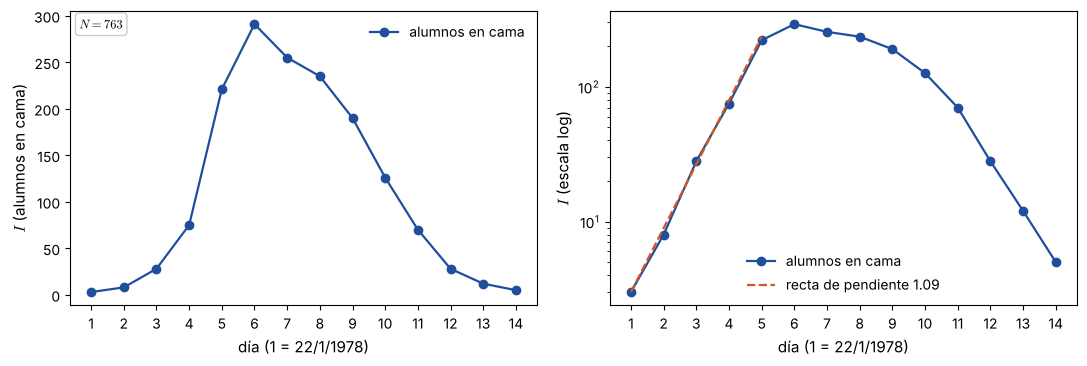

In [2]:
ruta = datos.obtener("gripe_internado_1978.csv")
d = np.genfromtxt(ruta, delimiter=",", names=True, dtype=None, encoding="utf-8")
t_d = d["dia"].astype(float)
I_d = d["en_cama"].astype(float)
N = 763

pendiente = np.polyfit(t_d[:4], np.log(I_d[:4]), 1)[0]
gamma_ojo = 1 / 2.5            # 2.5 días de cama
beta_ojo = pendiente + gamma_ojo
R0_ojo = beta_ojo / gamma_ojo
print(f"pendiente de log I (días 1-4): {pendiente:.3f} por día  ->  los casos se multiplican por {np.exp(pendiente):.2f} cada día")
print(f"a ojo: gamma = {gamma_ojo:.3f}, beta = {beta_ojo:.3f}, R0 = {R0_ojo:.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
for ax in (ax1, ax2):
    ax.plot(t_d, I_d, "o-", color=COLORES["dato"], label="alumnos en cama")
    ax.set_xlabel("día (1 = 22/1/1978)"); ax.set_xticks(range(1, 15))
ax1.set_ylabel("$I$ (alumnos en cama)"); ax1.legend()
ax2.set_yscale("log")
ax2.plot(t_d[:5], I_d[0] * np.exp(pendiente * (t_d[:5] - 1)), "--", color=COLORES["modelo"], label=rf"recta de pendiente {pendiente:.2f}")
ax2.set_ylabel("$I$ (escala log)"); ax2.legend()
estilo.parametros(ax1, rf"$N = {N}$", loc="upper left")
fig.tight_layout()

In [3]:
# Verificación
assert t_d.shape == (14,) and I_d.shape == (14,) and I_d.max() == 291, "los datos no se cargaron bien"
assert 0.8 < pendiente < 1.4, f"pendiente {pendiente:.2f}: se esperaba ~1 por día (usar log de I, días 1 a 4)"
assert 0.25 < gamma_ojo < 0.6, "gamma a ojo: la gripe dura 2 a 3 días -> gamma entre 0.33 y 0.5"
assert 2 < beta_ojo / gamma_ojo < 7, "R0 a ojo fuera de rango"
print(f"datos y estimación a ojo (R0 = {beta_ojo / gamma_ojo:.2f}): OK")

datos y estimación a ojo (R0 = 3.73): OK


## 2. Mínimos cuadrados no lineales

### El problema

Tenemos observaciones $y_k$ (alumnos en cama) en los instantes $t_k$, $k = 1, \dots, n$ ($n = 14$), y un modelo $I(t; p)$ que depende de un vector de parámetros $p = (\beta, \gamma, i_0)$. El **residuo** en el dato $k$ es $r_k(p) = I(t_k; p) - y_k$, y el ajuste por **mínimos cuadrados** busca el $p$ que minimiza la suma de cuadrados

$$C(p) = \sum_{k=1}^n r_k(p)^2 = \|r(p)\|^2 .$$

Es exactamente lo que hacen en Estadística con una recta, con dos diferencias. Primera: $I(t; p)$ no es lineal en $p$ (ni siquiera tiene fórmula: es la salida de `solve_ivp`), así que no hay ecuaciones normales que resolver de una vez; la minimización es **iterativa**, parte de un valor inicial $p^{(0)}$ y lo va corrigiendo. Segunda: como $C$ no es una parábola, puede tener **varios mínimos locales**, y a cuál llega el algoritmo depende de dónde arranca.

### Cómo funciona el algoritmo (Gauss–Newton)

Cerca del valor actual $p$, el residuo se linealiza: $r(p + \delta) \approx r(p) + J\,\delta$, donde $J$ es la **matriz jacobiana** $J_{kj} = \partial r_k/\partial p_j$ (de $n \times 3$). Con esa aproximación, $C(p + \delta)$ es cuadrática en $\delta$ y su mínimo es un problema de mínimos cuadrados *lineales*: $\delta = -(J^\top J)^{-1} J^\top r$. Se actualiza $p \leftarrow p + \delta$ y se repite hasta que $\delta$ o la mejora de $C$ sean despreciables. El algoritmo de **Levenberg–Marquardt** agrega un amortiguamiento que lo hace robusto lejos del mínimo; `scipy.optimize.least_squares` implementa una variante (`method="trf"`) que además admite **cotas** para los parámetros. La jacobiana se calcula por diferencias finitas: cada iteración cuesta unas $4$ resoluciones del sistema de EDOs, y un ajuste típico tarda entre 10 y 30 iteraciones.

### Las dos funciones de `scipy`

* `least_squares(fun, p0, bounds=(lo, hi), args=(...))`: `fun(p, *args)` devuelve el **vector de residuos** (no la suma de cuadrados: el algoritmo necesita cada $r_k$ para armar $J$). Devuelve un objeto con `x` (los parámetros), `fun` (los residuos en el óptimo), `jac` (la jacobiana en el óptimo), `cost` ($= \tfrac12\|r\|^2$, ojo con el $\tfrac12$), `nfev`, `success` y `message`.
* `curve_fit(f, t, y, p0=..., bounds=...)`: la interfaz "estadística": `f(t, *p)` devuelve el modelo, y la función arma los residuos sola. Devuelve `(popt, pcov)`, la estimación y su matriz de covarianza. Por dentro llama a `least_squares`. Es más cómoda cuando el modelo es una función de `t`; `least_squares` es más flexible (residuos pesados, varios conjuntos de datos, etc.). Acá usamos `least_squares` y comprobamos que `curve_fit` da lo mismo.

### Lo que hace falta para que funcione

**Valores iniciales razonables.** El algoritmo baja por el valle en el que arranca. Si $p^{(0)}$ está en cualquier lado, puede terminar en un mínimo local absurdo, o en una región donde el modelo no tiene sentido. La Tarea 1 es la receta para el SIR: $\gamma$ de la duración conocida de la enfermedad, $\beta$ de la pendiente inicial de $\log I$, $i_0$ del primer dato. En general: **usá todo lo que sepas del problema para elegir $p^{(0)}$**, y verificá graficando el modelo con $p^{(0)}$ antes de optimizar.

**Cotas.** Sin cotas, el optimizador va a probar $\gamma < 0$ o $i_0 < 0$ en alguna iteración: el SIR con parámetros negativos explota y `solve_ivp` falla o devuelve menos puntos de los pedidos, y el ajuste se cae con un error críptico. Con `bounds=([0.02, 0.02, 0], [20, 20, 0.5])` eso no pasa. Además, la función modelo tiene que devolver **siempre** un vector de la longitud correcta y finito: si `solve_ivp` no llega al final (`sol.success == False`, o `sol.y.shape[1] < len(t)`), conviene devolver un valor enorme, que el optimizador interpreta como "por acá no".

**Mínimos locales.** La única defensa práctica es arrancar desde varios $p^{(0)}$ distintos y comparar los `cost` finales: si todos llegan al mismo lugar, es muy probable que sea el mínimo global; si no, hay que quedarse con el menor y sospechar del problema (Tarea 5).

### Qué se obtiene además de los parámetros

**Residuos.** Siempre hay que graficarlos. Si el modelo es adecuado, los residuos se ven como ruido sin estructura, del tamaño del error de medición. Si tienen forma (positivos en un tramo, negativos en otro), el modelo se está perdiendo algo sistemático: en este laboratorio eso va a pasar en la cola de la epidemia.

**Intervalos aproximados.** Si los errores de medición son independientes con varianza $\sigma^2$, la linealización en el óptimo da la aproximación clásica de la covarianza de la estimación,

$$\operatorname{Cov}(\hat p) \approx \hat\sigma^2\,(J^\top J)^{-1},\qquad \hat\sigma^2 = \frac{\|r(\hat p)\|^2}{n - 3},$$

que es lo que `curve_fit` devuelve en `pcov`. La raíz de la diagonal son los **errores estándar** de cada parámetro; fuera de la diagonal está la **correlación** entre parámetros. Estos números son aproximados (valen si la linealización es buena y los errores son como se supuso, y acá los errores no son independientes ni gaussianos), pero sirven para dos cosas: dar una idea del orden de magnitud de la incertidumbre y, sobre todo, detectar **problemas de identificabilidad**.

**Identificabilidad.** Un parámetro es *identificable* si los datos lo determinan. Que no lo sea se ve de tres maneras equivalentes: (i) $J^\top J$ es casi singular y los errores estándar salen enormes; (ii) dos parámetros tienen correlación cercana a $\pm 1$: se pueden mover juntos sin que el ajuste cambie; (iii) la función $C(p)$ tiene un **valle** en lugar de un pozo: el optimizador se detiene en cualquier punto del fondo del valle según de dónde partió, y los "parámetros ajustados" cambian de una corrida a otra aunque el ajuste se vea igual. Para el SIR con datos de la fase de crecimiento solamente, los datos determinan $\beta - \gamma$ (la pendiente) e $i_0$, pero **no** $\beta$ y $\gamma$ por separado: el valle es la recta $\beta - \gamma = \text{cte}$, y $R_0$ queda sin determinar. Hacen falta el pico y la bajada, que dependen de $R_0$ y de $\gamma$ por separado, para fijar los tres.

### Tarea 2: El modelo SIR y la función que se ajusta

Escribí:

* `sir(t, u, beta, gamma)`: el campo del SIR en fracciones, con `u = (s, i)` (no hace falta $r$).
* `I_modelo(t, beta, gamma, i0)`: resuelve el SIR con `solve_ivp` desde $t_1 =$ `t[0]` con $(s, i)(t_1) = (1 - i_0, i_0)$, usando `t_eval=t`, `rtol=1e-8`, `atol=1e-10`, y devuelve $N\,i(t)$ en los instantes `t`. Si la integración falla o devuelve menos puntos que `len(t)`, tiene que devolver `np.full(len(t), 1e6)`.
* `residuos(p, t, y)`: `I_modelo(t, *p) - y`, en el formato que pide `least_squares`.

Graficá los datos junto con `I_modelo` en una grilla fina (`np.linspace(1, 14, 200)`) con los parámetros a ojo de la Tarea 1.

**Qué se espera.** La curva a ojo tiene que parecerse a los datos en forma y orden de magnitud (pico de unos cientos entre los días 5 y 8), aunque no los siga bien: si el pico es diez veces más chico o cae en el día 30, revisá la pendiente o las unidades (los parámetros son *por día*). Fijate que la función devuelve exactamente `len(t)` valores.

suma de cuadrados con los parámetros a ojo: 22193


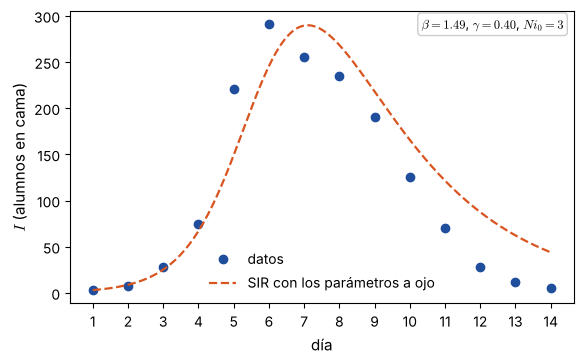

In [4]:
def sir(t, u, beta, gamma):
    """Campo del SIR en fracciones, u = (s, i)."""
    s, i = u
    return [-beta * s * i, beta * s * i - gamma * i]

def I_modelo(t, beta, gamma, i0):
    """Alumnos en cama según el SIR, N i(t), evaluado en los instantes t (t[0] es el día inicial)."""
    t = np.asarray(t, dtype=float)
    sol = solve_ivp(sir, (t[0], t[-1]), [1 - i0, i0], args=(beta, gamma), t_eval=t, rtol=1e-8, atol=1e-10)
    if not sol.success or sol.y.shape[1] != len(t):
        return np.full(len(t), 1e6)
    return N * sol.y[1]

def residuos(p, t, y):
    """Vector de residuos I_modelo(t; p) - y, con p = (beta, gamma, i0)."""
    return I_modelo(t, *p) - y

p_ojo = [beta_ojo, gamma_ojo, I_d[0] / N]
tt = np.linspace(1, 14, 200)
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(t_d, I_d, "o", color=COLORES["dato"], label="datos")
ax.plot(tt, I_modelo(tt, *p_ojo), "--", color=COLORES["modelo"], label="SIR con los parámetros a ojo")
ax.set_xlabel("día"); ax.set_ylabel("$I$ (alumnos en cama)"); ax.set_xticks(range(1, 15)); ax.legend()
estilo.parametros(ax, rf"$\beta = {p_ojo[0]:.2f}$, $\gamma = {p_ojo[1]:.2f}$, $N i_0 = {N * p_ojo[2]:.0f}$", loc="upper right" if I_modelo(tt, *p_ojo).argmax() < 100 else "upper left")
print(f"suma de cuadrados con los parámetros a ojo: {np.sum(residuos(p_ojo, t_d, I_d) ** 2):.0f}")

In [5]:
# Verificación: forma de la salida, conservación y una curva conocida
I_prueba = I_modelo(t_d, 1.76, 0.458, 0.003)
assert I_prueba.shape == (14,), "I_modelo debe devolver un valor por instante"
assert 250 < I_prueba.max() < 330 and 4 <= t_d[I_prueba.argmax()] <= 7, "con (1.76, 0.458, 0.003) el pico debería ser ~290 alrededor del día 6"
assert I_modelo(t_d, -1.0, 0.5, 0.003)[0] == 1e6 or np.all(np.isfinite(I_modelo(t_d, -1.0, 0.5, 0.003))), "la función debe ser robusta"
r_prueba = residuos([1.76, 0.458, 0.003], t_d, I_d)
assert r_prueba.shape == (14,) and np.abs(r_prueba).max() < 60, "residuos: forma o valores incorrectos"
print("modelo SIR y residuos: OK")

modelo SIR y residuos: OK


### Tarea 3: Ajuste con todos los datos

Ajustá $(\beta, \gamma, i_0)$ con `least_squares(residuos, p_ojo, args=(t_d, I_d), bounds=(lo, hi))`, con cotas `lo = [0.02, 0.02, 0]`, `hi = [20, 20, 0.5]` (las tasas, positivas: si $\beta$ o $\gamma$ fueran $0$ el modelo degenera). Guardá el resultado en `ajuste` y los parámetros en `beta_h, gamma_h, i0_h`. Después:

1. Imprimí $\beta$, $\gamma$, $1/\gamma$ (días de cama), $N i_0$, $R_0$ y el error relativo del ajuste $\|r\|/\|y\|$.
2. Comprobá que `curve_fit(I_modelo, t_d, I_d, p0=p_ojo, bounds=(lo, hi))` da los mismos parámetros, y calculá con la fórmula de la Sección 2 (o con `pcov`) los errores estándar y la matriz de correlación de los tres parámetros. Guardá la matriz de correlación en `corr`.
3. Figura con dos paneles: arriba, los datos y el modelo ajustado en grilla fina; abajo, los residuos $r_k$ como barras (`ax.bar`) con una línea en cero.
4. **Tamaño final.** Resolvé la relación del tamaño final $s_\infty = s_0\, e^{-R_0(1 - s_\infty)}$ con `brentq` y calculá cuántos alumnos se enferman en total según el modelo, $N(1 - s_\infty)$. Compará con una estimación hecha *solo con los datos*: como $\dot r = \gamma i$, el total de contagiados es $\gamma\int_0^\infty I\,dt$, y la integral se aproxima con la suma de los datos (cada dato es un día en cama por alumno): `total_datos = gamma_h * I_d.sum()`.

**Qué se espera.** Un ajuste visualmente bueno con error relativo alrededor del 10 %, $R_0$ entre 3 y 5 y una duración de la infección de unos 2 días. Los residuos ($r_k = $ modelo $-$ dato) *no* van a ser ruido puro: mirá el signo en los días 8 a 10 y en los días 12 a 14, y anotalo para la interpretación: ¿la epidemia real baja como la exponencial del modelo? En la matriz de correlación, buscá el par más correlacionado y pensá por qué (pista: ¿qué dos cosas fijan la altura de la curva en los primeros días?). El tamaño final del modelo va a decir que se enferma casi todo el internado; la estimación con los datos da algo parecido pero no igual; anotá los dos números.

`ftol` termination condition is satisfied. (8 evaluaciones)
beta = 1.761 /día, gamma = 0.458 /día (1/gamma = 2.18 días), N i0 = 2.26
R0 = 3.85;  error relativo del ajuste: 10.9 %;  RMSE = 16.4 alumnos


curve_fit coincide: True | pcov coincide: True
  beta  = 1.7614 ± 0.1066
  gamma = 0.4579 ± 0.0194
  i0    = 0.0030 ± 0.0013
correlación (beta, gamma, i0):
[[ 1.    0.61 -0.96]
 [ 0.61  1.   -0.56]
 [-0.96 -0.56  1.  ]]


s_inf = 0.0233: según el modelo se enferman 745 de 763 alumnos (97.7 %)
estimación con los datos, gamma * sum(I) = 0.458 * 1547 = 708 alumnos


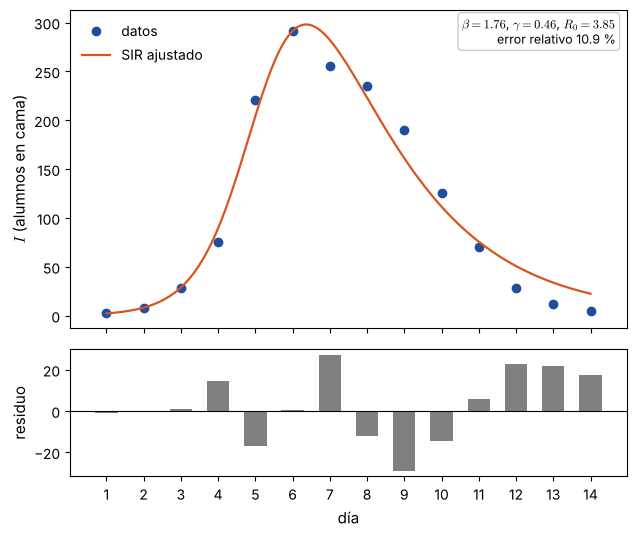

In [6]:
lo, hi = [0.02, 0.02, 0], [20, 20, 0.5]
ajuste = least_squares(residuos, p_ojo, args=(t_d, I_d), bounds=(lo, hi))
beta_h, gamma_h, i0_h = ajuste.x
R0_h = beta_h / gamma_h
err_rel = np.linalg.norm(ajuste.fun) / np.linalg.norm(I_d)
print(ajuste.message, f"({ajuste.nfev} evaluaciones)")
print(f"beta = {beta_h:.3f} /día, gamma = {gamma_h:.3f} /día (1/gamma = {1 / gamma_h:.2f} días), N i0 = {N * i0_h:.2f}")
print(f"R0 = {R0_h:.2f};  error relativo del ajuste: {100 * err_rel:.1f} %;  RMSE = {np.sqrt(np.mean(ajuste.fun ** 2)):.1f} alumnos")

# curve_fit: misma respuesta, y su covarianza coincide con sigma^2 (J^T J)^-1
popt, pcov = curve_fit(I_modelo, t_d, I_d, p0=p_ojo, bounds=(lo, hi))
J = ajuste.jac
sigma2 = np.sum(ajuste.fun ** 2) / (len(t_d) - 3)
cov = sigma2 * np.linalg.inv(J.T @ J)
se = np.sqrt(np.diag(cov))
corr = cov / np.outer(se, se)
print("curve_fit coincide:", np.allclose(popt, ajuste.x, rtol=1e-3), "| pcov coincide:", np.allclose(pcov, cov, rtol=1e-2))
for nombre, v, e in zip(["beta", "gamma", "i0"], ajuste.x, se):
    print(f"  {nombre:5s} = {v:.4f} ± {e:.4f}")
print("correlación (beta, gamma, i0):"); print(np.round(corr, 2))

tt = np.linspace(1, 14, 200)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.5, 5.5), sharex=True, gridspec_kw={"height_ratios": [3, 1.2]})
ax1.plot(t_d, I_d, "o", color=COLORES["dato"], label="datos")
ax1.plot(tt, I_modelo(tt, *ajuste.x), color=COLORES["modelo"], label="SIR ajustado")
ax1.set_ylabel("$I$ (alumnos en cama)"); ax1.legend(loc="upper left")
estilo.parametros(ax1, rf"$\beta = {beta_h:.2f}$, $\gamma = {gamma_h:.2f}$, $R_0 = {R0_h:.2f}$" + "\n" + rf"error relativo {100 * err_rel:.1f} %", loc="upper right")
ax2.bar(t_d, ajuste.fun, color=COLORES["gris"], width=0.6)
ax2.axhline(0, color="black", lw=0.8)
ax2.set_xlabel("día"); ax2.set_ylabel("residuo"); ax2.set_xticks(range(1, 15))
fig.tight_layout()

def s_final(R0, s0):
    """Solución s_inf de s = s0 exp(-R0 (1 - s)) con brentq (la raíz menor que 1/R0; si s0 = 1, s = 1 también es raíz)."""
    return brentq(lambda s: s - s0 * np.exp(-R0 * (1 - s)), 1e-12, min(s0, 1 / R0))

s_inf = s_final(R0_h, 1 - i0_h)
total_modelo = N * (1 - s_inf)
total_datos = gamma_h * I_d.sum()
print(f"s_inf = {s_inf:.4f}: según el modelo se enferman {total_modelo:.0f} de {N} alumnos ({100 * (1 - s_inf):.1f} %)")
print(f"estimación con los datos, gamma * sum(I) = {gamma_h:.3f} * {I_d.sum():.0f} = {total_datos:.0f} alumnos")

In [7]:
# Verificación
assert ajuste.success, ajuste.message
assert 2 < R0_h < 6, f"R0 = {R0_h:.2f}: se esperaba entre 2 y 6"
assert 1.5 < 1 / gamma_h < 3.5, f"1/gamma = {1 / gamma_h:.2f} días: se esperaba 2 a 3"
assert np.linalg.norm(ajuste.fun) / np.linalg.norm(I_d) < 0.15, "el error relativo del ajuste completo debería ser < 15 %"
assert corr.shape == (3, 3) and np.allclose(np.diag(corr), 1), "corr debe ser la matriz de correlación 3 x 3"
assert abs(s_final(2.0, 1.0) - 0.2032) < 1e-3, "s_final(2, 1) debería dar ~0.203 (ver las notas)"
assert 700 < total_modelo <= N, "el tamaño final del modelo debería ser casi todo el internado"
print(f"ajuste completo (R0 = {R0_h:.2f}, 1/gamma = {1 / gamma_h:.2f} d, s_inf = {s_inf:.3f}): OK")

ajuste completo (R0 = 3.85, 1/gamma = 2.18 d, s_inf = 0.023): OK


**Para el docente.** Valores del ajuste completo: $\beta = 1.761$, $\gamma = 0.458$ ($1/\gamma = 2.18$ días), $N i_0 = 2.26$, $R_0 = 3.85$; error relativo 10.9 %, RMSE 16.4 alumnos; errores estándar $\pm 0.11$, $\pm 0.019$, $\pm 0.0013$; correlación $(\beta, i_0) = -0.96$ (los dos fijan la altura inicial: más $i_0$ con menos $\beta$ da la misma curva los primeros días), $(\beta,\gamma) = 0.61$. $s_\infty = 0.023$: el modelo dice que se enferman 745 de 763; con $\gamma \sum I = 708$. El informe original del BMJ (a verificar en la fuente: es el número que se cita habitualmente con este dato) habla de 512 alumnos que pasaron por la cama, es decir el 67 %: el modelo sobreestima el tamaño final. Es un buen ejemplo de "lo que el modelo no puede decir": los residuos (modelo $-$ dato) son negativos en los días 8 a 10 (hasta $-29$ el día 9: los datos se mantienen altos después del pico) y positivos en los días 12 a 14 (unos $+20$: los datos caen a casi cero mientras el modelo sigue una exponencial lenta). Es la firma de una duración de cama *fija* (todos salen a los 3 o 4 días) contra la remoción a tasa constante del SIR, que supone duraciones exponenciales con muchos casos cortos y una cola larga. Además, seguramente hubo alumnos con síntomas leves fuera de la enfermería. Sobre las cotas: si alguien las omite, `solve_ivp` falla en una iteración con parámetros negativos y aparece un error de "broadcast" de `numpy`: es el momento de explicar por qué la función modelo tiene que ser robusta. Tiempo: Tareas 1 a 3, unos 80 minutos.

## 3. Validación: ajustar no es predecir

Con tres parámetros libres y catorce datos, que la curva ajustada pase cerca de los puntos no dice mucho sobre la capacidad del modelo de *anticipar* algo. La prueba honesta es la que se hace en aprendizaje automático: **ajustar con una parte de los datos y evaluar en la otra**. Acá la partición natural es temporal, porque es la situación real de un epidemiólogo a mitad de un brote: con los datos hasta hoy, ¿qué va a pasar?

Distinguimos dos errores:

* **Error de ajuste** (*in-sample*): $\|r\|$ sobre los datos usados en la optimización. Baja siempre que se agregan parámetros.
* **Error de predicción** (*out-of-sample*): la distancia entre el modelo y los datos que *no* se usaron. Es el que mide la utilidad del modelo, y puede *empeorar* al agregar parámetros: un modelo más flexible ajusta mejor el ruido de la primera mitad y lo extrapola.

Para la predicción importan dos cosas distintas: el **pico** (cuándo y qué altura), que en el SIR queda fijado por $R_0$ y la pendiente inicial, y la **cola** (qué tan rápido baja), que depende de $\gamma$. Van a ver que no se predicen igual de bien.

### Tarea 4: Ajustar con la primera mitad, predecir la segunda

Ajustá el SIR usando **solo los primeros 7 días** (`t_d[:7]`, `I_d[:7]`), partiendo de `p_ojo` y con las mismas cotas; guardá el resultado en `ajuste_mitad`. Con esos parámetros:

1. Graficá los datos completos (distinguiendo con colores los 7 usados y los 7 reservados), la curva del modelo en toda la ventana y una línea vertical en la frontera.
2. Calculá el error relativo del ajuste sobre los primeros 7 días y el error relativo de la predicción sobre los últimos 7, y guardalos en `err_ajuste` y `err_pred`.
3. Compará el pico predicho (día y altura, con `I_modelo` sobre una grilla fina) con el observado (día 6, 291), y la predicción para los días 8, 9 y 10 con los datos.
4. Compará $R_0$ y $\gamma$ de este ajuste con los del ajuste completo.

**Qué se espera.** El pico se predice sorprendentemente bien (a un día y a unas decenas de alumnos), porque a los 7 días ya están el crecimiento y el comienzo de la bajada. La cola no: el modelo baja más rápido que los datos en los días 8 a 11 y el error de predicción es diez veces el de ajuste. Anotá los dos errores y los residuos de los días 8 a 10 para la interpretación.

primera mitad: beta = 2.088, gamma = 0.548 (1/gamma = 1.82 d), R0 = 3.81   [ajuste completo: R0 = 3.85, gamma = 0.458]
error relativo de ajuste (días 1-7): 2.8 %;  de predicción (días 8-14): 32.7 %
pico predicho: día 6.1, 295 alumnos;  observado: día 6, 291
  día 8: predicho 178, observado 235
  día 9: predicho 116, observado 190
  día 10: predicho 73, observado 126


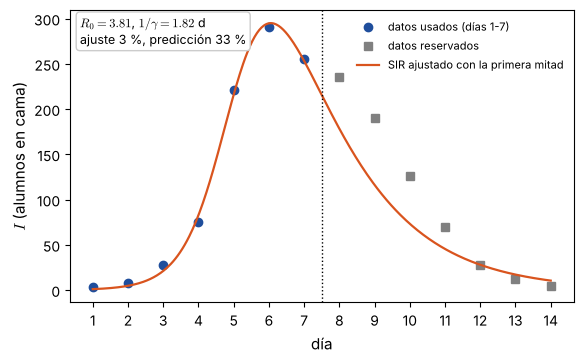

In [8]:
m = 7
ajuste_mitad = least_squares(residuos, p_ojo, args=(t_d[:m], I_d[:m]), bounds=(lo, hi))
p_mitad = ajuste_mitad.x
I_pred = I_modelo(t_d, *p_mitad)
err_ajuste = np.linalg.norm(I_pred[:m] - I_d[:m]) / np.linalg.norm(I_d[:m])
err_pred = np.linalg.norm(I_pred[m:] - I_d[m:]) / np.linalg.norm(I_d[m:])
tt = np.linspace(1, 14, 400)
I_tt = I_modelo(tt, *p_mitad)
print(f"primera mitad: beta = {p_mitad[0]:.3f}, gamma = {p_mitad[1]:.3f} (1/gamma = {1 / p_mitad[1]:.2f} d), R0 = {p_mitad[0] / p_mitad[1]:.2f}"
      f"   [ajuste completo: R0 = {R0_h:.2f}, gamma = {gamma_h:.3f}]")
print(f"error relativo de ajuste (días 1-{m}): {100 * err_ajuste:.1f} %;  de predicción (días {m + 1}-14): {100 * err_pred:.1f} %")
print(f"pico predicho: día {tt[I_tt.argmax()]:.1f}, {I_tt.max():.0f} alumnos;  observado: día {t_d[I_d.argmax()]:.0f}, {I_d.max():.0f}")
for k in [7, 8, 9]:
    print(f"  día {t_d[k]:.0f}: predicho {I_pred[k]:.0f}, observado {I_d[k]:.0f}")

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(t_d[:m], I_d[:m], "o", color=COLORES["dato"], label=f"datos usados (días 1-{m})")
ax.plot(t_d[m:], I_d[m:], "s", color=COLORES["gris"], label="datos reservados")
ax.plot(tt, I_tt, color=COLORES["modelo"], label="SIR ajustado con la primera mitad")
ax.axvline(m + 0.5, color="black", ls=":", lw=1)
ax.set_xlabel("día"); ax.set_ylabel("$I$ (alumnos en cama)"); ax.set_xticks(range(1, 15)); ax.legend(loc="upper right", fontsize=8)
estilo.parametros(ax, rf"$R_0 = {p_mitad[0] / p_mitad[1]:.2f}$, $1/\gamma = {1 / p_mitad[1]:.2f}$ d" + "\n" + rf"ajuste {100 * err_ajuste:.0f} %, predicción {100 * err_pred:.0f} %", loc="upper left")

In [9]:
# Verificación
assert ajuste_mitad.success
I_chk = I_modelo(tt, *p_mitad)
assert abs(tt[I_chk.argmax()] - 6) <= 1.2 and abs(I_chk.max() - 291) < 60, "el pico debería predecirse a ~1 día y ~60 alumnos"
assert err_pred > 1.5 * err_ajuste, "el error de predicción debería ser bastante mayor que el de ajuste"
assert np.all(I_modelo(t_d, *p_mitad)[7:10] < I_d[7:10]), "la cola predicha debería quedar por debajo de los datos (días 8-10)"
assert 2 < p_mitad[0] / p_mitad[1] < 6
print(f"validación (ajuste {100 * err_ajuste:.0f} %, predicción {100 * err_pred:.0f} %): OK")

validación (ajuste 3 %, predicción 33 %): OK


**Para el docente.** Con 7 días: $\beta = 2.088$, $\gamma = 0.548$ ($1/\gamma = 1.82$ d), $R_0 = 3.81$; error de ajuste 2.8 %, de predicción 32.7 %. Pico predicho: día 6.0, 295 alumnos (observado día 6, 291). Días 8, 9, 10: predichos 178, 116, 73 contra 235, 190, 126. $R_0$ casi no cambia respecto del ajuste completo (3.81 vs 3.85) pero $\gamma$ sí (0.55 vs 0.46): la cola es lo que fija $\gamma$, y sin la cola el ajuste elige un $\gamma$ mayor que exagera la bajada. Vale la pena que prueben `m = 5` y `m = 6` (con 5 días $\gamma$ se va a la cota inferior y $R_0$ sale absurdo: es la no identificabilidad de la Sección 4, y anticipa la Tarea 5). Tiempo: 30 minutos.

## 4. ¿Qué determinan los datos? Mínimos locales e identificabilidad

Dos preguntas distintas que se confunden fácil:

1. **¿El optimizador encontró el mínimo global?** Se contesta arrancando desde muchos puntos iniciales. Si todos terminan en el mismo `cost` y los mismos parámetros, el mínimo es único (dentro de las cotas). Si terminan en `cost` distintos, hay mínimos locales y hay que quedarse con el mejor.
2. **¿El mínimo determina los parámetros?** Puede pasar que todos los arranques lleguen al mismo `cost` pero a parámetros *distintos*: el fondo de $C(p)$ es un valle y no un pozo. Eso es **no identificabilidad**: hay una dirección en el espacio de parámetros a lo largo de la cual el modelo no cambia (o cambia menos que el ruido). Los parámetros individuales no tienen sentido, pero las combinaciones transversales al valle sí.

La herramienta más directa para verlo es un **mapa del error**: graficar $C(\beta, \gamma)$ con curvas de nivel en un rectángulo alrededor del óptimo (con $i_0$ fijo en su valor ajustado, para poder dibujar en dos dimensiones). Un pozo redondo significa que $\beta$ y $\gamma$ están bien determinados; un valle alargado, que solo la combinación transversal lo está. Con los datos completos y con los de la fase de crecimiento solamente (días 1 a 5) los mapas son muy diferentes, y eso explica por qué a mitad de un brote es tan difícil estimar $R_0$.

Para leer el mapa conviene dibujar también las rectas $\beta - \gamma = \text{pendiente inicial}$ (lo que fija el crecimiento) y $\beta/\gamma = R_0$ (lo que fija el pico y el tamaño final).

### Tarea 5: Varios puntos iniciales y el mapa del error

1. Generá 10 puntos iniciales al azar con `rng = np.random.default_rng(0)`: $\beta \sim U(0.5, 5)$, $\gamma \sim U(0.1, 2)$, $i_0 \sim U(0.001, 0.03)$. Desde cada uno ajustá con todos los datos y guardá en `resultados` (array de forma `(10, 5)`) las columnas $\beta$, $\gamma$, $i_0$, $R_0$, `cost`. Imprimí la tabla. ¿Llegan todos al mismo lugar? ¿Mismo $R_0$?
2. Repetí desde los mismos puntos iniciales usando **solo los días 1 a 5** (`resultados_5`). ¿Qué pasa ahora con $\beta$, $\gamma$ y $R_0$? ¿Y con $\beta - \gamma$? ¿Y con `cost`?
3. Escribí `mapa_error(t, y, betas, gammas, i0)` que devuelva la matriz $C_{jk} = \sum_k r_k(\beta_k, \gamma_j, i_0)^2$ (forma `(len(gammas), len(betas))`) y graficá con `ax.contour` (niveles en escala logarítmica: `levels=np.geomspace(C.min(), C.max(), 15)`) dos paneles: todos los datos, y solo los días 1 a 5; en cada uno marcá el óptimo, la recta $\beta - \gamma = $ `pendiente` y la recta $\beta = R_0\,\gamma$ con el $R_0$ del ajuste completo. Usá `betas = np.linspace(0.8, 3.5, 40)`, `gammas = np.linspace(0.02, 1.2, 40)` e `i0 = i0_h` (unas 3200 resoluciones del sistema: tarda unos 10 segundos).

**Qué se espera.** Con todos los datos, todos los arranques dan los mismos parámetros a cuatro cifras y el mapa muestra un pozo cerrado, alargado en diagonal ($\beta$ y $\gamma$ pueden subir juntos con poco costo: ¿qué combinación de los dos fijan mejor los datos?). Con 5 días, el `cost` final es el mismo para todos pero $\gamma$ se pega a la cota inferior y $R_0$ sale absurdo (¡más de 100!), y el mapa muestra un valle abierto a lo largo de $\beta - \gamma \approx$ pendiente: los datos de la fase de crecimiento determinan la diferencia, no el cociente. Describí en una línea qué dato "cierra" el valle.

todos los datos:   beta    gamma    i0      R0      cost
[[   1.7614    0.4579    0.003     3.8469 1873.0958]
 [   1.7614    0.4579    0.003     3.8469 1873.0958]
 [   1.7614    0.4579    0.003     3.8469 1873.0958]
 [   1.7614    0.4579    0.003     3.8469 1873.0958]
 [   1.7614    0.4579    0.003     3.8469 1873.0958]
 [   1.7614    0.4579    0.003     3.847  1873.0958]
 [   1.7614    0.4579    0.003     3.8469 1873.0958]
 [   1.7614    0.4579    0.003     3.8469 1873.0958]
 [   1.7614    0.4579    0.003     3.8469 1873.0958]
 [   1.7614    0.4579    0.003     3.8469 1873.0958]]
  dispersión de R0: 3.4e-07 (relativa)

días 1 a 5:        beta    gamma    i0      R0      cost
[[ 1.2961  0.02    0.0025 64.8037 16.5448]
 [ 1.2961  0.02    0.0025 64.8037 16.5448]
 [ 1.2961  0.02    0.0025 64.8037 16.5448]
 [ 1.2961  0.02    0.0025 64.8037 16.5448]
 [ 1.2961  0.02    0.0025 64.8037 16.5448]
 [ 1.2961  0.02    0.0025 64.8037 16.5448]
 [ 1.2961  0.02    0.0025 64.8037 16.5448]
 [ 1.2961  0.0

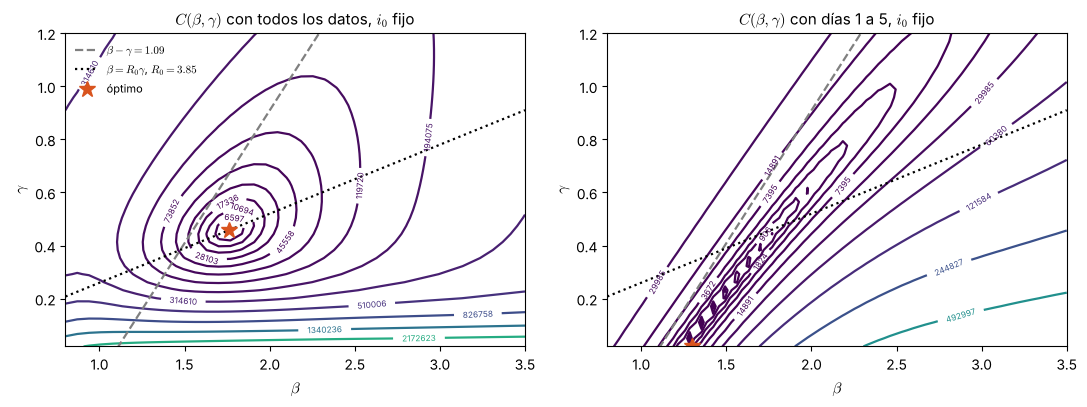

In [10]:
rng = np.random.default_rng(0)
inicios = np.column_stack([rng.uniform(0.5, 5, 10), rng.uniform(0.1, 2, 10), rng.uniform(0.001, 0.03, 10)])

def ajustar_desde(inicios, t, y):
    """Ajusta desde cada fila de `inicios`; devuelve un array (n, 5): beta, gamma, i0, R0, cost."""
    filas = []
    for p0 in inicios:
        a = least_squares(residuos, p0, args=(t, y), bounds=(lo, hi))
        filas.append([*a.x, a.x[0] / a.x[1], a.cost])
    return np.array(filas)

resultados = ajustar_desde(inicios, t_d, I_d)
resultados_5 = ajustar_desde(inicios, t_d[:5], I_d[:5])
np.set_printoptions(precision=4, suppress=True, linewidth=120)
print("todos los datos:   beta    gamma    i0      R0      cost"); print(resultados)
print(f"  dispersión de R0: {resultados[:, 3].std() / resultados[:, 3].mean():.1e} (relativa)")
print("\ndías 1 a 5:        beta    gamma    i0      R0      cost"); print(resultados_5)
print(f"  beta - gamma: {np.round(resultados_5[:, 0] - resultados_5[:, 1], 3)}  (pendiente inicial: {pendiente:.3f})")
np.set_printoptions()

def mapa_error(t, y, betas, gammas, i0):
    """Matriz C[j, k] = suma de cuadrados de los residuos con (betas[k], gammas[j], i0)."""
    return np.array([[np.sum(residuos([b, g, i0], t, y) ** 2) for b in betas] for g in gammas])

betas, gammas = np.linspace(0.8, 3.5, 40), np.linspace(0.02, 1.2, 40)
mapas = [("todos los datos", mapa_error(t_d, I_d, betas, gammas, i0_h), resultados[0, :2]),
         ("días 1 a 5", mapa_error(t_d[:5], I_d[:5], betas, gammas, i0_h), resultados_5[0, :2])]
fig, axs = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (titulo, C, opt) in zip(axs, mapas):
    cs = ax.contour(betas, gammas, C, levels=np.geomspace(C.min(), C.max(), 15), cmap="viridis")
    ax.clabel(cs, fmt="%.0f", fontsize=6)
    ax.plot(betas, betas - pendiente, "--", color=COLORES["gris"], label=rf"$\beta - \gamma = {pendiente:.2f}$")
    ax.plot(betas, betas / R0_h, ":", color="black", label=rf"$\beta = R_0\gamma$, $R_0 = {R0_h:.2f}$")
    ax.plot(*opt, "*", color=COLORES["modelo"], ms=12, label="óptimo")
    ax.set_xlim(betas[0], betas[-1]); ax.set_ylim(gammas[0], gammas[-1])
    ax.set_xlabel(r"$\beta$"); ax.set_ylabel(r"$\gamma$"); ax.set_title(f"$C(\\beta, \\gamma)$ con {titulo}, $i_0$ fijo")
axs[0].legend(loc="upper left", fontsize=8)
fig.tight_layout()

In [11]:
# Verificación
assert resultados.shape == (10, 5) and resultados_5.shape == (10, 5)
assert resultados[:, 3].std() / resultados[:, 3].mean() < 1e-3, "con todos los datos todos los arranques deberían dar el mismo R0"
assert np.allclose(resultados[:, 4], resultados[0, 4], rtol=1e-3), "con todos los datos el costo final debería ser único"
assert resultados_5[:, 3].max() > 20, "con 5 días R0 debería quedar indeterminado (gamma en la cota)"
assert np.allclose(resultados_5[:, 0] - resultados_5[:, 1], pendiente, atol=0.4), "con 5 días beta - gamma debería seguir la pendiente inicial"
C_chk = mapa_error(t_d, I_d, np.array([beta_h]), np.array([gamma_h]), i0_h)
assert C_chk.shape == (1, 1) and abs(C_chk[0, 0] - 2 * ajuste.cost) < 1, "mapa_error en el óptimo debería dar 2*cost"
print("identificabilidad: OK")

identificabilidad: OK


**Para el docente.** Con todos los datos, los 10 arranques convergen a $(1.7614, 0.4579, 0.0030)$ con `cost` $= 1873.1$ ($= \tfrac12 \sum r^2$), a cuatro cifras. Con 5 días: `cost` $= 16.5$ para todos, pero $\gamma$ queda en la cota inferior ($0.02$), $\beta \approx 1.30$, $R_0 \approx 65$ (con cota $0$ da $10^{18}$); $\beta - \gamma \approx 1.28$ para todos, cerca de la pendiente 1.09 (no igual, porque para el día 5 ya $s$ bajó a 0.7 y el crecimiento dejó de ser exponencial). Nota: con $i_0$ fijo en el mapa, el valle de los 5 días no es exactamente la recta $\beta - \gamma =$ pendiente sino una curva algo más empinada, por la misma razón; el mensaje (un valle abierto contra un pozo cerrado) se ve igual. El pozo con todos los datos es alargado en diagonal, en una dirección intermedia entre $\beta - \gamma = $ cte (pendiente 1) y $\beta = R_0\gamma$ (pendiente $1/R_0$), más cerca de la primera: es la correlación $+0.61$ entre $\beta$ y $\gamma$. La lectura: lo que los datos fijan con más rigidez es la tasa de crecimiento $\beta - \gamma$; el cociente $R_0$ (que fija el pico y el tamaño final) y la escala temporal $1/\gamma$ están determinados, pero con más holgura. Vale conectar con la observación de las notas de que, en tiempo $\tau = \gamma t$, el SIR tiene a $R_0$ como único parámetro: mover $(\beta, \gamma)$ sobre $\beta = R_0\gamma$ cambia solo la escala de tiempo. El mapa tarda unos 10 s. Tiempo: 45 minutos.

## 5. Un modelo más rico: SEIR y la comparación de modelos

La gripe tiene un período de **latencia**: entre el contagio y el momento en que alguien transmite (y cae en cama) pasan uno o dos días. El modelo SEIR del ejercicio de las notas agrega el compartimento de *expuestos* $e$ y una tasa $\sigma$ de pasaje a infeccioso ($1/\sigma$ es la latencia media):

$$\dot s = -\beta s i,\qquad \dot e = \beta s i - \sigma e,\qquad \dot i = \sigma e - \gamma i,\qquad \dot r = \gamma i .$$

Con $i(t_1) = i_0$, $e(t_1) = 0$, los parámetros son cuatro: $(\beta, \sigma, \gamma, i_0)$. $R_0$ sigue siendo $\beta/\gamma$ (la latencia retrasa los contagios pero no cambia cuántos hace cada infectado), pero la tasa de crecimiento inicial $\rho$ ya no es $\beta - \gamma$ sino la raíz positiva de $(\rho + \sigma)(\rho + \gamma) = \beta\sigma$: para la misma pendiente observada, el SEIR necesita un $\beta$ mayor.

**Más parámetros no siempre es mejor.** Un modelo con más parámetros ajusta *siempre* al menos igual de bien (el SIR es el caso $\sigma \to \infty$ del SEIR), así que comparar los errores de ajuste no dice nada. Las preguntas correctas son:

1. ¿La mejora del ajuste es *grande* comparada con lo que se espera por agregar un parámetro? (En Estadística: el test $F$ de modelos anidados, o criterios como AIC/BIC, que penalizan el número de parámetros.) Con 14 datos y errores que no son independientes, cualquiera de estos criterios es aproximado; lo usamos como guía.
2. ¿Mejora la **predicción**? Repetir la validación de la Tarea 4 con el SEIR es la prueba decisiva.
3. ¿Los parámetros ajustados son **razonables** y están **determinados**? Si el SEIR necesita $R_0 = 13$ o una latencia de una hora para mejorar el ajuste, está usando el parámetro extra para acomodar ruido, no para describir un mecanismo. Los errores estándar y las correlaciones lo delatan.

Es exactamente el dilema sesgo–varianza: el SEIR tiene menos sesgo (es más realista) pero más varianza (con 14 datos, cuatro parámetros son muchos).

### Tarea 6: SEIR: ¿mejora el ajuste?, ¿mejora la predicción?

Escribí `seir(t, u, beta, sigma, gamma)` con `u = (s, e, i)`, `I_seir(t, beta, sigma, gamma, i0)` (misma estructura que `I_modelo`, con $e(t_1) = 0$) y `residuos_seir(p, t, y)`. Después:

1. Ajustá el SEIR con todos los datos, con cotas `[0, 0.2, 0, 0]` y `[30, 10, 20, 0.5]` ($1/\sigma$ entre 0.1 y 5 días) y valor inicial `[beta_h, 1.0, gamma_h, i0_h]`. Imprimí $\beta$, $1/\sigma$, $1/\gamma$, $R_0$, el error relativo y los errores estándar; compará `cost` con el del SIR.
2. Calculá el estadístico $F = \dfrac{(C_{SIR} - C_{SEIR}) / 1}{C_{SEIR} / (n - 4)}$ (con $C = \sum r^2$): si es menor que ~5 (el valor crítico al 5 % para 1 y 10 grados de libertad es 4.96), la mejora no es distinguible del ruido.
3. Repetí la validación: ajustá el SEIR con los primeros 7 días y calculá el error de predicción sobre los últimos 7 (`err_pred_seir`). Compará con `err_pred` del SIR.
4. Figura con los datos, el SIR y el SEIR ajustados con todos los datos (arriba) y los residuos de ambos (abajo).

**Qué se espera.** El SEIR ajusta un poco mejor (unos 15 % menos de suma de cuadrados), pero con $R_0$ y $\beta$ muy grandes y errores estándar enormes: el parámetro extra está mal determinado. El $F$ sale por debajo del crítico, y el error de predicción no mejora. Escribí en una línea cuál de los dos modelos elegirías para *predecir* y por qué.

SEIR: beta = 6.31 ± 2.60, 1/sigma = 1.41 d (sigma = 0.71 ± 0.15), 1/gamma = 2.11 d (gamma = 0.474 ± 0.019), N i0 = 2.14, R0 = 13.3
suma de cuadrados: SIR 3746, SEIR 3101 (17 % menos); error relativo SEIR 9.9 %
estadístico F = 2.08  (crítico al 5 % con (1, 10) g.l.: 4.96)


predicción con 7 días: SIR 32.7 %, SEIR 32.3 %  (SEIR con 7 días: R0 = 10.7, 1/sigma = 1.07 d)


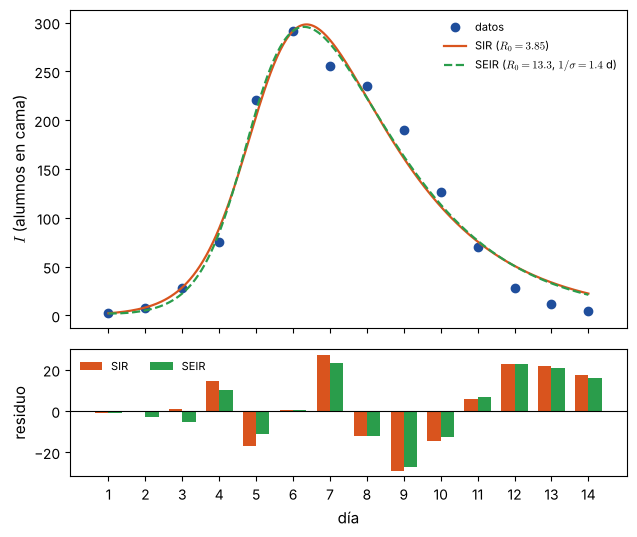

In [12]:
def seir(t, u, beta, sigma, gamma):
    """Campo del SEIR en fracciones, u = (s, e, i)."""
    s, e, i = u
    return [-beta * s * i, beta * s * i - sigma * e, sigma * e - gamma * i]

def I_seir(t, beta, sigma, gamma, i0):
    """Alumnos en cama según el SEIR, con e(t1) = 0, i(t1) = i0."""
    t = np.asarray(t, dtype=float)
    sol = solve_ivp(seir, (t[0], t[-1]), [1 - i0, 0.0, i0], args=(beta, sigma, gamma), t_eval=t, rtol=1e-8, atol=1e-10)
    if not sol.success or sol.y.shape[1] != len(t):
        return np.full(len(t), 1e6)
    return N * sol.y[2]

def residuos_seir(p, t, y):
    return I_seir(t, *p) - y

lo_s, hi_s = [0, 0.2, 0, 0], [30, 10, 20, 0.5]
p0_seir = [beta_h, 1.0, gamma_h, i0_h]
ajuste_seir = least_squares(residuos_seir, p0_seir, args=(t_d, I_d), bounds=(lo_s, hi_s))
bS, sS, gS, i0S = ajuste_seir.x
C_sir, C_seir = np.sum(ajuste.fun ** 2), np.sum(ajuste_seir.fun ** 2)
n = len(t_d)
cov_s = np.sum(ajuste_seir.fun ** 2) / (n - 4) * np.linalg.inv(ajuste_seir.jac.T @ ajuste_seir.jac)
se_s = np.sqrt(np.diag(cov_s))
print(f"SEIR: beta = {bS:.2f} ± {se_s[0]:.2f}, 1/sigma = {1 / sS:.2f} d (sigma = {sS:.2f} ± {se_s[1]:.2f}), "
      f"1/gamma = {1 / gS:.2f} d (gamma = {gS:.3f} ± {se_s[2]:.3f}), N i0 = {N * i0S:.2f}, R0 = {bS / gS:.1f}")
print(f"suma de cuadrados: SIR {C_sir:.0f}, SEIR {C_seir:.0f} ({100 * (1 - C_seir / C_sir):.0f} % menos); "
      f"error relativo SEIR {100 * np.linalg.norm(ajuste_seir.fun) / np.linalg.norm(I_d):.1f} %")
F = (C_sir - C_seir) / (C_seir / (n - 4))
print(f"estadístico F = {F:.2f}  (crítico al 5 % con (1, {n - 4}) g.l.: 4.96)")

ajuste_seir_mitad = least_squares(residuos_seir, p0_seir, args=(t_d[:m], I_d[:m]), bounds=(lo_s, hi_s))
I_pred_seir = I_seir(t_d, *ajuste_seir_mitad.x)
err_pred_seir = np.linalg.norm(I_pred_seir[m:] - I_d[m:]) / np.linalg.norm(I_d[m:])
print(f"predicción con 7 días: SIR {100 * err_pred:.1f} %, SEIR {100 * err_pred_seir:.1f} %  "
      f"(SEIR con 7 días: R0 = {ajuste_seir_mitad.x[0] / ajuste_seir_mitad.x[2]:.1f}, 1/sigma = {1 / ajuste_seir_mitad.x[1]:.2f} d)")

tt = np.linspace(1, 14, 300)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.5, 5.5), sharex=True, gridspec_kw={"height_ratios": [3, 1.2]})
ax1.plot(t_d, I_d, "o", color=COLORES["dato"], label="datos")
ax1.plot(tt, I_modelo(tt, *ajuste.x), color=COLORES["modelo"], label=rf"SIR ($R_0 = {R0_h:.2f}$)")
ax1.plot(tt, I_seir(tt, *ajuste_seir.x), "--", color=CICLO[2], label=rf"SEIR ($R_0 = {bS / gS:.1f}$, $1/\sigma = {1 / sS:.1f}$ d)")
ax1.set_ylabel("$I$ (alumnos en cama)"); ax1.legend(loc="upper right", fontsize=8)
ax2.bar(t_d - 0.18, ajuste.fun, width=0.36, color=COLORES["modelo"], label="SIR")
ax2.bar(t_d + 0.18, ajuste_seir.fun, width=0.36, color=CICLO[2], label="SEIR")
ax2.axhline(0, color="black", lw=0.8); ax2.legend(fontsize=8, ncol=2)
ax2.set_xlabel("día"); ax2.set_ylabel("residuo"); ax2.set_xticks(range(1, 15))
fig.tight_layout()

In [13]:
# Verificación
assert ajuste_seir.success
assert C_seir < C_sir, "el SEIR (que contiene al SIR) no puede ajustar peor"
assert F < 4.96, f"F = {F:.2f}: con estos datos la mejora del SEIR no debería ser significativa"
assert err_pred_seir > 0.8 * err_pred, "el SEIR no debería predecir la cola claramente mejor que el SIR"
assert bS / gS > 6 or se_s[0] / bS > 0.3, "el R0 del SEIR debería salir grande o muy incierto"
print(f"SEIR (F = {F:.2f}, predicción {100 * err_pred_seir:.0f} % vs {100 * err_pred:.0f} %): OK")

SEIR (F = 2.08, predicción 32 % vs 33 %): OK


**Para el docente.** SEIR con todos los datos: $\beta = 6.3$, $1/\sigma = 1.41$ d, $1/\gamma = 2.11$ d, $R_0 = 13.3$, $N i_0 = 2.1$; suma de cuadrados 3101 contra 3746 del SIR (17 % menos), error relativo 9.9 %; $F = 2.08 < 4.96$. Con 7 días: error de predicción 32.3 % (SIR: 32.7 %), $R_0 = 10.7$. Los errores estándar del SEIR son grandes (el de $\beta$ es comparable a $\beta$) y $\beta$, $\sigma$ tienen correlación cercana a $-1$: con la pendiente inicial fija, $\beta$ y $\sigma$ se compensan. El punto para la discusión: un $R_0 = 13$ para una gripe es absurdo (el sarampión anda por ahí), y el modelo lo "necesita" solo para reproducir la subida abrupta entre los días 4 y 5 con una latencia. Con $\sigma$ fijo en un valor plausible ($1/\sigma = 1$ d) el ajuste es apenas peor que el SIR y $R_0$ vuelve a ~4: buena consigna extra si sobra tiempo. Tiempo: 40 minutos.

## 6. (Opcional) ¿Qué habría pasado con vacunación o aislamiento?

La pregunta 4 del problema conductor. Con el modelo ajustado se pueden simular contrafácticos que los datos no contienen:

* **Vacunación** previa de una fracción $v$: $s(t_1) = 1 - v - i_0$. La teoría dice que no hay epidemia si $R_0 (1 - v) < 1$, es decir $v > 1 - 1/R_0$ (inmunidad de rebaño); para $R_0 \approx 3.85$, hace falta vacunar al 74 %.
* **Aislamiento** a partir de un día $t_a$: los enfermos en cama contagian menos, lo que se modela con $\beta(t) = \beta$ para $t < t_a$ y $\beta(t) = \beta\, f$ (con $f < 1$) después. Como el SIR es autónomo, lo más simple es integrar en dos tramos, con el estado final del primero como inicial del segundo.

Estos escenarios son *lo que el modelo dice*, no lo que habría pasado: son tan confiables como las hipótesis del modelo (mezcla homogénea, $\gamma$ constante, "en cama" = "infeccioso"), y la Tarea 4 mostró que la cola no está bien capturada. Aun así, la respuesta cualitativa (cuánto reduce el pico cada medida) es lo que un modelo así aporta.

### Tarea 7: Vacunación e intervención a partir del día 5

Con los parámetros del ajuste completo:

1. `curva_vacunados(v, T=14)`: devuelve la curva $I(t)$ en `tt = np.linspace(1, 14, 300)` con $s(t_1) = 1 - v - i_0$, y el valor de $s$ en $t = T$ (para el tamaño final, llamala con `T=60`). Graficá para $v = 0, 0.25, 0.5, 0.74, 0.9$ y anotá el pico de cada una. Calculá `v_rebano = 1 - 1/R0_h`.
2. `curva_aislamiento(f, t_a=5, T=14)`: integrá con $\beta$ hasta $t_a$ y con $\beta f$ después (dos llamadas a `solve_ivp`, la segunda desde el estado final de la primera); misma salida. Graficá para $f = 1, 0.7, 0.5, 0.3$.
3. Para cada escenario calculá el tamaño final (¡acá ya no vale la fórmula de $s_\infty$ con $s_0 = 1$ en el caso del aislamiento: integrá hasta $t = 60$ y leé $s$!).

**Qué se espera.** Con $v = 0.74$ el pico casi desaparece (queda $R_0 s_0 \approx 1$) y con $v = 0.5$ el pico baja a una quinta parte aunque $R_0 s_0 \approx 1.9$ sigue siendo mayor que 1. Con aislamiento desde el día 5 el pico se reduce pero no desaparece (ya hay 221 en cama y muchos incubando), y el tamaño final baja bastante. Comentá qué medida es más eficaz y cuál es más realista de implementar en un internado.

umbral de inmunidad de rebaño: v = 1 - 1/R0 = 0.74


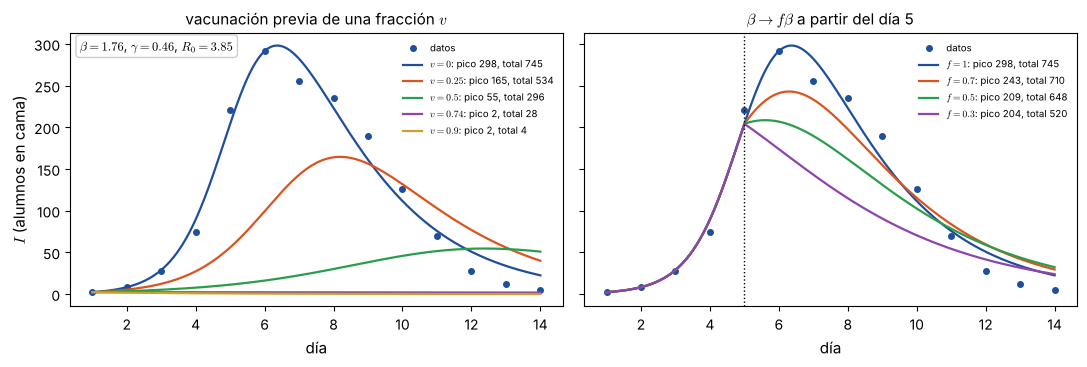

In [14]:
tt = np.linspace(1, 14, 300)

def curva_vacunados(v, T=14):
    """Fracción v vacunada al inicio: s(t1) = 1 - v - i0. Devuelve (I en tt, s en t = T)."""
    sol = solve_ivp(sir, (1, T), [1 - v - i0_h, i0_h], args=(beta_h, gamma_h), dense_output=True, rtol=1e-8, atol=1e-10)
    return N * sol.sol(tt)[1], sol.y[0, -1]

def curva_aislamiento(f, t_a=5, T=14):
    """beta reducida al factor f a partir del día t_a. Devuelve (I en tt, s en t = T)."""
    s1 = solve_ivp(sir, (1, t_a), [1 - i0_h, i0_h], args=(beta_h, gamma_h), dense_output=True, rtol=1e-8, atol=1e-10)
    s2 = solve_ivp(sir, (t_a, T), s1.y[:, -1], args=(f * beta_h, gamma_h), dense_output=True, rtol=1e-8, atol=1e-10)
    I = np.where(tt < t_a, N * s1.sol(np.minimum(tt, t_a))[1], N * s2.sol(np.maximum(tt, t_a))[1])
    return I, s2.y[0, -1]

v_rebano = 1 - 1 / R0_h
print(f"umbral de inmunidad de rebaño: v = 1 - 1/R0 = {v_rebano:.2f}")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
ax1.plot(t_d, I_d, "o", color=COLORES["dato"], ms=4, label="datos")
for v, c in zip([0, 0.25, 0.5, 0.74, 0.9], CICLO):
    I, s_fin = curva_vacunados(v, T=60)
    ax1.plot(tt, I, color=c, label=rf"$v = {v}$: pico {I.max():.0f}, total {N * (1 - v - s_fin):.0f}")
ax1.set_title("vacunación previa de una fracción $v$"); ax1.set_xlabel("día"); ax1.set_ylabel("$I$ (alumnos en cama)"); ax1.legend(fontsize=7)
ax2.plot(t_d, I_d, "o", color=COLORES["dato"], ms=4, label="datos")
for f, c in zip([1, 0.7, 0.5, 0.3], CICLO):
    I, s_fin = curva_aislamiento(f, T=60)
    ax2.plot(tt, I, color=c, label=rf"$f = {f}$: pico {I.max():.0f}, total {N * (1 - s_fin):.0f}")
ax2.axvline(5, color="black", ls=":", lw=1)
ax2.set_title(r"$\beta \to f\beta$ a partir del día 5"); ax2.set_xlabel("día"); ax2.legend(fontsize=7)
estilo.parametros(ax1, rf"$\beta = {beta_h:.2f}$, $\gamma = {gamma_h:.2f}$, $R_0 = {R0_h:.2f}$", loc="upper left")
fig.tight_layout()

In [15]:
# Verificación
I_v, _ = curva_vacunados(0.5)
I_0, _ = curva_vacunados(0.0)
assert abs(I_0.max() - I_modelo(tt, *ajuste.x).max()) < 1, "con v = 0 debe reproducir el ajuste"
assert I_v.max() < 0.3 * I_0.max(), "con v = 0.5 el pico debería bajar a menos de un tercio"
I_r, _ = curva_vacunados(v_rebano + 0.05)
assert I_r.max() < 1.2 * N * i0_h, "por encima del umbral de rebaño no hay epidemia"
I_a, _ = curva_aislamiento(0.5)
assert np.allclose(I_a[tt < 5], I_0[tt < 5], rtol=1e-3) and I_a.max() < I_0.max(), "aislamiento: igual hasta el día 5, pico menor después"
print("intervenciones: OK")

intervenciones: OK


## 7. (Opcional) La misma pregunta en otro modelo: la logística y la población de un país

Lo que vimos con el SIR no es una rareza de la epidemiología. Tomemos el modelo más simple del Capítulo 2, la logística $\dot P = rP(1 - P/K)$, cuya solución es

$$P(t) = \frac{K}{1 + \left(K/P_0 - 1\right)e^{-rt}},$$

y ajustémosla a la población de algunos países entre 1960 y 2021 (datos del Banco Mundial, `poblacion_banco_mundial.csv`; ver `datos/README.md`). Los parámetros son tres: $P_0$, la tasa $r$ y la capacidad de carga $K$. La pregunta es la misma de la Sección 4: **¿qué determinan los datos?** Mientras la población crece lejos de $K$, la logística es indistinguible de la exponencial $P_0e^{rt}$ y $K$ no aparece en los datos: es el valle de los cinco primeros días de la epidemia. $K$ solo se puede estimar cuando la curva ya *se dobló*, igual que $R_0$ solo se estima después del pico.

Hay además una lección nueva. Los errores estándar de la Sección 2 suponen que **el modelo es correcto** y que lo único que separa el modelo de los datos es ruido. Con la población, el error de medición es minúsculo y lo que domina es el error del *modelo* (migraciones, cambios en la natalidad, la logística no puede decrecer): los errores estándar salen diminutos y, aun así, la estimación de $K$ se mueve mucho más que eso cuando se agregan datos.

### Tarea 8: (Opcional) Exponencial contra logística, y cuánto vale el error estándar de K

Cargá `poblacion_banco_mundial.csv` con `np.genfromtxt(..., delimiter=",", names=True)` (columnas `anio`, `argentina`, `nigeria`, `japon`, `corea_del_sur`, `china`, `mundo`, en habitantes). Trabajá en millones de habitantes y con $t = $ año $- 1960$.

1. Escribí `P_exp(t, P0, r)`, `P_log(t, P0, r, K)` y `ajustar(t, P)`, que ajuste las dos con `curve_fit` y devuelva `(pe, pl, se)`: los parámetros de la exponencial, los de la logística y los errores estándar de la logística. Para la logística usá `p0=(P[0], 0.03, 2 * P[-1])` y cotas `([0, 0, 0], [np.inf, 1, 1e6])` (es decir, $K$ hasta un billón de habitantes: si el ajuste se va a la cota, $K$ no está determinado).
2. Para los seis casos, guardá en el diccionario `tabla` (clave: nombre de la columna) la tupla `(r_exp, err_exp, r_log, K, se_K, err_log)`, donde los errores son el RMSE relativo a la media de $P$. Imprimí la tabla y graficá datos y ajustes para Argentina, Nigeria, Japón y Corea del Sur (cuatro paneles).
3. Para Argentina, ajustá la logística con los datos hasta 1980, 1990, 2000, 2010 y 2021, y guardá en `K_arg` un array de forma `(5, 2)` con $K$ y su error estándar. Graficá $K$ con barras de error (`ax.errorbar`) en función del último año usado.

**Qué se espera.** Para Nigeria, $K$ se va a la cota con un error estándar absurdo y $r$ coincide con el de la exponencial: los datos no ven ninguna desaceleración. Para Japón y Corea, $K$ sale con un error estándar de décimas de millón… y aun así está mal: la población de Japón empezó a bajar en 2010 (mirá los residuos), y la de Corea, en 2021. En Argentina, cada estimación de $K$ cae muy lejos de la anterior, fuera de sus propias barras de error. Anotá los números para la interpretación.

                 exponencial          logística
                 r        error       r        K (millones)          error
argentina       0.0129    2.4 %     0.0264       66.64 ± 0.86       0.47 %
nigeria         0.0263    0.6 %     0.0263       1e+06 ± 8.12e+07   0.63 %
japon           0.0045    4.4 %     0.0695       129.5 ± 0.417      1.05 %
corea_del_sur   0.0101    5.0 %     0.0478       55.05 ± 0.148      0.44 %
china           0.0114    5.3 %     0.0461        1533 ± 7.54       0.73 %
mundo           0.0151    2.7 %     0.0284   1.212e+04 ± 74.2       0.23 %


Argentina, datos hasta 1980: K = 1e+06 ± 1.85e+09 millones
Argentina, datos hasta 1990: K = 221 ± 34 millones
Argentina, datos hasta 2000: K = 88.42 ± 4.19 millones
Argentina, datos hasta 2010: K = 66.38 ± 1.5 millones
Argentina, datos hasta 2021: K = 66.64 ± 0.86 millones


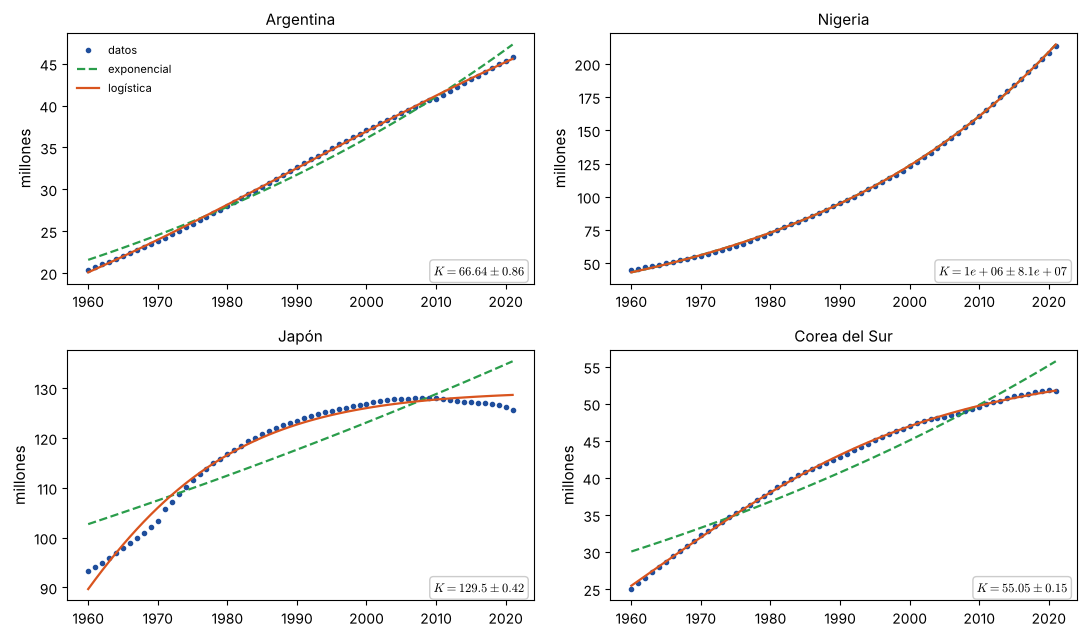

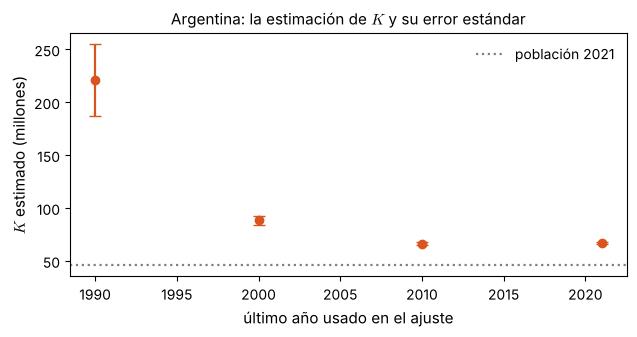

In [16]:
ruta = datos.obtener("poblacion_banco_mundial.csv")
pob = np.genfromtxt(ruta, delimiter=",", names=True)
anio = pob["anio"]
t_p = anio - 1960
paises = ["argentina", "nigeria", "japon", "corea_del_sur", "china", "mundo"]

def P_exp(t, P0, r):
    return P0 * np.exp(r * t)

def P_log(t, P0, r, K):
    return K / (1 + (K / P0 - 1) * np.exp(-r * t))

def ajustar(t, P):
    """Ajusta exponencial y logística; devuelve (pe, pl, se) con se = errores estándar de la logística."""
    pe, _ = curve_fit(P_exp, t, P, p0=(P[0], 0.02))
    pl, cl = curve_fit(P_log, t, P, p0=(P[0], 0.03, 2 * P[-1]), bounds=([0, 0, 0], [np.inf, 1, 1e6]), max_nfev=20000)
    return pe, pl, np.sqrt(np.diag(cl))

tabla = {}
print("                 exponencial          logística")
print("                 r        error       r        K (millones)          error")
for p in paises:
    P = pob[p] / 1e6
    pe, pl, se = ajustar(t_p, P)
    err_e = np.sqrt(np.mean((P_exp(t_p, *pe) - P) ** 2)) / P.mean()
    err_l = np.sqrt(np.mean((P_log(t_p, *pl) - P) ** 2)) / P.mean()
    tabla[p] = (pe[1], err_e, pl[1], pl[2], se[2], err_l)
    print(f"{p:14s}  {pe[1]:.4f}   {100 * err_e:4.1f} %     {pl[1]:.4f}   {pl[2]:9.4g} ± {se[2]:<9.3g}  {100 * err_l:4.2f} %")

fig, axs = plt.subplots(2, 2, figsize=(11, 6.5))
for ax, p in zip(axs.flat, ["argentina", "nigeria", "japon", "corea_del_sur"]):
    P = pob[p] / 1e6
    pe, pl, se = ajustar(t_p, P)
    ax.plot(anio, P, "o", ms=3, color=COLORES["dato"], label="datos")
    ax.plot(anio, P_exp(t_p, *pe), "--", color=CICLO[2], label="exponencial")
    ax.plot(anio, P_log(t_p, *pl), color=COLORES["modelo"], label="logística")
    ax.set_title({"argentina": "Argentina", "nigeria": "Nigeria", "japon": "Japón", "corea_del_sur": "Corea del Sur"}[p]); ax.set_ylabel("millones")
    estilo.parametros(ax, rf"$K = {pl[2]:.4g} \pm {se[2]:.2g}$", loc="lower right")
axs[0, 0].legend(loc="upper left", fontsize=8)
fig.tight_layout()

P = pob["argentina"] / 1e6
finales = [1980, 1990, 2000, 2010, 2021]
K_arg = []
for f in finales:
    _, pl, se = ajustar(t_p[anio <= f], P[anio <= f])
    K_arg.append([pl[2], se[2]])
K_arg = np.array(K_arg)
for f, (K, s) in zip(finales, K_arg):
    print(f"Argentina, datos hasta {f}: K = {K:.4g} ± {s:.3g} millones")
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ok = K_arg[:, 0] < 1e5
ax.errorbar(np.array(finales)[ok], K_arg[ok, 0], yerr=K_arg[ok, 1], fmt="o", capsize=4, color=COLORES["modelo"])
ax.axhline(P[-1], color=COLORES["gris"], ls=":", label="población 2021")
ax.set_xlabel("último año usado en el ajuste"); ax.set_ylabel("$K$ estimado (millones)"); ax.legend()
ax.set_title("Argentina: la estimación de $K$ y su error estándar")
fig.tight_layout()

In [17]:
# Verificación
assert set(tabla) == set(paises) and all(len(v) == 6 for v in tabla.values())
assert tabla["nigeria"][3] > 1e4, "Nigeria: K debería irse a la cota (no identificable)"
assert abs(tabla["nigeria"][2] - tabla["nigeria"][0]) < 1e-3, "Nigeria: r de la logística = r de la exponencial"
assert 125 < tabla["japon"][3] < 135 and tabla["japon"][4] < 1, "Japón: K ~ 130 con error estándar chico"
assert tabla["argentina"][5] < tabla["argentina"][1], "la logística debería ajustar mejor que la exponencial"
assert K_arg.shape == (5, 2)
saltos = np.abs(np.diff(K_arg[1:, 0])) / K_arg[2:, 1]
assert saltos[:2].min() > 3, "las estimaciones de K deberían moverse más que su error estándar"
print("logística y población: OK")

logística y población: OK


**Para el docente.** Tabla (millones): Argentina $r = 0.0264$, $K = 66.6 \pm 0.9$ (error 0.5 % contra 2.4 % de la exponencial); Nigeria $K$ en la cota ($10^6$) con error estándar $\sim 10^8$ y $r = 0.0263$ igual al de la exponencial; Japón $K = 129.5 \pm 0.4$ (máximo real: 128.1 en 2010, y bajando); Corea $K = 55.05 \pm 0.15$ (máximo real: 51.8 en 2020; está 20 errores estándar por encima); China $K = 1533 \pm 8$; mundo $K = 12\,120 \pm 74$ (las proyecciones de Naciones Unidas, *World Population Prospects 2024*, dan un máximo de unos 10 300 millones hacia 2080: otra vez, decenas de errores estándar). Argentina según el último año: 1980, $K$ en la cota (no identificable, como la epidemia a los 5 días); 1990, $221 \pm 34$; 2000, $88 \pm 4$; 2010, $66.4 \pm 1.5$; 2021, $66.6 \pm 0.9$. Cada salto es de 4 a 30 errores estándar: el error estándar mide la incertidumbre *si el modelo fuera cierto*, y acá lo que domina es el error de modelo. Es la contracara de la Tarea 5: allá el problema era que los datos no alcanzaban; acá alcanzan de sobra y el problema es el modelo. Los datos y la idea vienen de la guía de laboratorio de 2023 (ejercicio del Banco Mundial). Tiempo: 30 minutos.

**Para el docente.** Picos (y totales, integrando hasta el día 60) con vacunación: $v = 0$: 298 (745); $0.25$: 165 (534); $0.5$: 55 (296, con el pico recién el día 12: la epidemia se estira); $0.74$: 2 (28: no hay epidemia); $0.9$: 2 (4). Aislamiento desde el día 5 (el modelo tiene 204 en cama ese día): $f = 0.7$: pico 243 (710); $0.5$: 209 (648); $0.3$: 204, es decir el propio día 5 (520). La discusión interesante: el aislamiento el día 5 llega tarde porque en el SIR ajustado el pico es el día 6 y $s$ ya bajó a 0.6; reduce poco el pico y bastante el total; con $t_a = 3$ el efecto es mucho mayor (proponerlo). La vacunación al 50 % no evita la epidemia ($R_0 s_0 = 1.9$) pero la reduce a un quinto y la estira: es la diferencia entre "aplanar" y "evitar". Tiempo: 30 minutos; es opcional.

## Interpretación

Esta es la parte que se evalúa. Respondé en las celdas de texto que siguen, con oraciones completas y citando los números o gráficos que obtuviste.

**1.** **Parámetros e interpretación.** Informá $\beta$, $\gamma$, $R_0$ y $s_\infty$ del ajuste completo con sus errores estándar, y traducilos a lenguaje epidemiológico (días de cama, contagios por infectado, fracción que se enferma). ¿Son plausibles para una gripe en un internado? ¿Qué par de parámetros está más correlacionado y por qué (pensá qué determina la altura de la curva los primeros días)?

**2.** **Ajustar contra predecir.** Con los números de la Tarea 4: ¿qué predijo bien el modelo ajustado con la primera mitad y qué no? Explicá, usando lo que cada parámetro controla, por qué el pico se predice mejor que la cola. ¿Qué te dicen los residuos del ajuste completo (signo en los días 8 a 10 y en los últimos) sobre lo que le falta al modelo?

**3.** **Identificabilidad.** Describí los dos mapas del error de la Tarea 5. ¿Qué combinación de $\beta$ y $\gamma$ determinan los datos de la fase de crecimiento, y por qué? ¿Qué información de la curva es la que permite estimar $R_0$? Con esto, explicá por qué a mitad de un brote (antes del pico) las estimaciones de $R_0$ son tan inciertas aunque los datos parezcan seguir perfectamente una exponencial.

**4.** **SIR contra SEIR.** El SEIR ajusta mejor. Con el estadístico $F$, los errores estándar, el valor de $R_0$ que necesita y el error de predicción, argumentá cuál de los dos modelos elegirías para (a) describir esta epidemia, (b) predecir la segunda mitad a partir de la primera. ¿Qué haría falta (más datos, otro tipo de datos, o fijar algún parámetro) para que el SEIR fuera preferible?

**5.** **Qué puede decir el modelo y qué no.** Escribí el párrafo de conclusión que pide el ejercicio de las notas: qué responde el SIR ajustado sobre esta epidemia (las preguntas 1 a 4 del problema conductor, con números) y qué no puede decir, mencionando al menos tres hipótesis del modelo o del dato (por ejemplo: qué es \"en cama\" respecto de \"infeccioso\", la mezcla homogénea, $\gamma$ constante, el tamaño final del modelo contra el de los datos) y cómo afectan la confianza en las predicciones y en los escenarios de la Tarea 7.

**6.** **(Si hiciste la Tarea 8.)** ¿En qué se parece el problema de estimar $K$ con la población de Nigeria al de estimar $R_0$ con los primeros cinco días de la epidemia? Para Argentina, Japón y Corea los errores estándar de $K$ son chicos: ¿por qué no hay que creerles? ¿Qué mide el error estándar y qué no mide?

### Respuestas modelo (para el docente)

**1.** $\beta = 1.76 \pm 0.11$ por día, $\gamma = 0.458 \pm 0.019$ por día ($1/\gamma = 2.2$ días de cama), $N i_0 = 2.3 \pm 1.0$, $R_0 = 3.85$ (propagando: $\pm 0.2$ aproximadamente), $s_\infty = 0.023$ (se enferma el 97.7 %, 745 alumnos). Plausibles: 2 días de cama es lo típico de una gripe; $R_0 \approx 4$ es alto para la gripe en población general (1.5–3) pero un internado es una población densa y bien mezclada, justo la hipótesis del modelo. El par más correlacionado es $(\beta, i_0)$ con $-0.96$: en los primeros días $I \approx N i_0 e^{(\beta - \gamma)(t - 1)}$, y un $i_0$ mayor con un $\beta$ menor da casi la misma curva; los datos de la subida fijan bien el producto "altura por crecimiento", no cada factor.

**2.** Pico bien (día 6.0 y 295 contra día 6 y 291); cola mal: predice 178, 116, 73 para los días 8–10 contra 235, 190, 126 (error de predicción 33 % contra 5 % de ajuste). El pico queda fijado por $R_0$ e $i_0$ (el pico ocurre cuando $s = 1/R_0$ y su altura es $1 - (1 + \ln R_0)/R_0$), y a los 7 días la curva ya empezó a bajar: $R_0$ está determinado. La cola la controla $\gamma$ (bajada como $e^{-\gamma t}$ cuando $s \ll 1/R_0$), y con 7 días $\gamma$ está sobreestimado (0.55 contra 0.46). Los residuos (modelo $-$ dato) del ajuste completo son negativos en los días 8–10 (hasta $-29$) y positivos en los días 12–14 ($\approx +20$): después del pico los datos se mantienen altos y después caen a casi cero, mientras el modelo baja como una exponencial, más rápido al principio y más lento al final. El SIR supone que los infectados dejan la cama a tasa constante (duraciones exponenciales: muchos casos cortos y una cola larga); la realidad se parece más a una duración fija de 3 o 4 días, que produce esa forma de meseta y caída.

**3.** Con todos los datos, un pozo cerrado, alargado en diagonal: $\beta$ y $\gamma$ pueden subir juntos (manteniendo aproximadamente $\beta - \gamma$) con poco costo, porque la tasa de crecimiento inicial es lo que los datos fijan con más rigidez; el cociente y la escala de tiempo están determinados pero con más holgura (correlación $0.61$). Con 5 días, un valle abierto: los datos determinan $\beta - \gamma$ (tasa de crecimiento; $i_0$ también) y no $\beta/\gamma$; $\gamma$ se va a la cota y $R_0$ sale cualquier cosa ($\approx 65$ con la cota en $0.02$, $10^{18}$ con la cota en $0$) con el mismo costo. Lo que permite estimar $R_0$ es la *desaceleración*: cuándo y a qué altura la curva se aparta de la exponencial, o sea el pico (y después la cola, para $\gamma$). Por eso a mitad de un brote la exponencial se ve perfecta y $R_0$ es inestimable sin información externa (la duración de la infección, medida clínicamente: es exactamente lo que hicimos "a ojo" en la Tarea 1, y lo que se hace en la práctica).

**4.** SEIR: suma de cuadrados 3101 contra 3746, $F = 2.1 < 4.96$: la mejora no es significativa; $R_0 = 13$ (absurdo para una gripe; corresponde a sarampión) con errores estándar del orden del valor, $\beta$ y $\sigma$ correlacionados casi $-1$; predicción de la segunda mitad igual de mala (32 % contra 33 %). Para describir, cualquiera de los dos es aceptable, pero los parámetros del SEIR no significan nada; para predecir, el SIR: mismo error con menos parámetros y valores interpretables. Para que el SEIR fuera preferible haría falta fijar $\sigma$ con información clínica (latencia de la gripe, 1–2 días), o datos de otro tipo (fechas de inicio de síntomas, contactos) o una serie más larga con más de una onda.

**5.** El párrafo debe contener: (1) hay epidemia porque $R_0 s_0 \approx 3.8 > 1$; (2) el pico se alcanza cuando $s = 1/R_0 = 0.26$, el día 6, con un 38 % del internado en cama; (3) según el modelo se enferma el 98 % ($s_\infty = 0.023$); (4) hacía falta vacunar al 74 % para evitarla, y un aislamiento el día 5 reduce poco el pico y algo el total. Y lo que no puede decir: el tamaño final del modelo (745) es mayor que la estimación con los datos ($\gamma\sum I = 708$) y que lo que informa la fuente original (512 alumnos pasaron por la cama, si el dato es correcto): el modelo supone remoción a tasa constante (y por eso su cola exponencial no reproduce la meseta y caída de los datos) e identifica "en cama" con "infeccioso"; la mezcla homogénea ignora la estructura (dormitorios, cursos) que probablemente frenó la epidemia antes; el $\gamma$ ajustado incluye el tiempo de cama y no el de contagio; y los escenarios de la Tarea 7 heredan todas estas limitaciones: son comparaciones cualitativas entre medidas, no predicciones numéricas.

**6.** (Tarea 8.) Es el mismo valle: mientras la población crece sin desacelerarse, la logística coincide con la exponencial y los datos fijan $r$ (como fijaban $\beta-\gamma$) pero no $K$ (como no fijaban $R_0$); hace falta ver la curva doblarse. En Argentina, Japón y Corea los datos sí ven la desaceleración, y los errores estándar son chicos, pero el error estándar mide cuánto variaría $K$ si el modelo fuera exacto y las diferencias con los datos fueran ruido independiente; no mide el error de *modelo*. Cuando la logística es una mala descripción (migración, caída de la natalidad, una población que decrece), la estimación se mueve decenas de errores estándar al agregar datos (Argentina: 221, 88, 66) y queda lejos de lo que pasó después (Corea, Japón).

**Tiempos.** Tareas 1–3: 80 min; Tarea 4: 30; Tarea 5: 45; Tarea 6: 40; Tareas 7 y 8 (opcionales): 30 cada una; interpretación: en casa. Si el tiempo es justo, la Tarea 7 se salta y la 6 puede hacerse solo con el ajuste completo (sin la validación).